# Reproducible backtests: pin the data, not just the code

Every quant team has lived this incident: a backtest from March cannot be
reproduced in July. The code is in git, the params are in the run log — but
the *data* moved underneath it. The vendor restated history (split fixes,
dividend corrections, survivorship patches) and the "same" backtest now
prints a different Sharpe. Git solved this for code; h5i-db solves it for
data: every write is an immutable version, and a named snapshot pins the
exact bytes a run consumed — at O(1) cost, because a snapshot is a manifest
pin, not a copy.

This recipe demonstrates the failure concretely (restate → naive re-run →
different Sharpe), then the fix (snapshot-pinned re-run → **bit-identical**
results, asserted), and finishes with a minimal run-registry pattern.

In [1]:
import hashlib
import json

import numpy as np
import pandas as pd
import pyarrow as pa
import h5i_db

import cookbook_utils as cu

db = h5i_db.Database(cu.fresh_db("prod_repro"), create=True)

## 1. Load the price panel (data version 1)

Twenty synthetic names, ~3 years of daily closes. With
`sort_key=["ts", "symbol"]` the input must be sorted by the full key —
a daily panel has 20 symbols per timestamp, so ts-only order is not enough.

In [2]:
symbols = [f"STK{i:03d}" for i in range(20)]
panel = cu.make_daily_prices(symbols=symbols, days=750)

schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("symbol", pa.string()),
        pa.field("close", pa.float64()),
    ]
)
db.create_table("prices", schema, time_column="ts", sort_key=["ts", "symbol"])
db.append(
    "prices",
    panel.select(["ts", "symbol", "close"]).sort_by([("ts", "ascending"), ("symbol", "ascending")]),
    note="vendor delivery v1",
)

{'table': 'prices',
 'sequence': 1,
 'op': 'append',
 'rows_total': 15000,
 'segments_total': 1,
 'segments_added': 1,
 'segments_deduped': 0,
 'committed_at_ns': 1784776201582493359}

## 2. A backtest that takes its read point as a parameter

The one design decision that makes reproducibility possible: the backtest
never hardcodes `FROM prices`. It takes a *relation* — the live table, a
pinned snapshot `h5i('prices', 'bt-run-001')`, a version number, or an
as-of timestamp — and everything downstream is a pure function of that
read point plus params.

The strategy itself is deliberately plain (126-day momentum, monthly
rebalance, top-5 equal weight): the point is the plumbing, not the alpha.

In [3]:
def run_backtest(read_point: str, lookback: int = 126, top_n: int = 5) -> dict:
    """Momentum backtest against any h5i-db relation. Deterministic."""
    px = db.sql(
        f"SELECT ts, symbol, close FROM {read_point} ORDER BY ts, symbol"
    ).to_pandas()
    wide = px.pivot(index="ts", columns="symbol", values="close").sort_index()

    mom = wide.pct_change(lookback)
    month_keys = wide.index.tz_convert(None).to_period("M")
    month_ends = wide.groupby(month_keys).tail(1).index
    weights = pd.DataFrame(0.0, index=wide.index, columns=wide.columns)
    for i, d in enumerate(month_ends[:-1]):
        if mom.loc[d].isna().all():
            continue  # still inside the lookback warm-up
        winners = mom.loc[d].nlargest(top_n).index
        in_month = (wide.index > d) & (wide.index <= month_ends[i + 1])
        weights.loc[in_month, winners] = 1.0 / top_n

    daily_ret = (weights * wide.pct_change()).sum(axis=1)
    curve = (1.0 + daily_ret).cumprod()
    sharpe = float(daily_ret.mean() / daily_ret.std() * np.sqrt(252))
    digest = hashlib.sha256(np.ascontiguousarray(curve.to_numpy()).tobytes()).hexdigest()
    return {"curve": curve, "sharpe": sharpe, "sha256": digest}

## 3. Pin the read point, then run

Before the research run, take a named snapshot. It freezes the manifest of
`prices` as of this instant — no data is copied, and no later write can
touch what the name resolves to.

In [4]:
db.snapshot("bt-run-001", tables=["prices"], note="data pin for momentum study 001")

run1 = run_backtest("h5i('prices', 'bt-run-001')")
print(f"run 1  sharpe={run1['sharpe']:.6f}  curve sha256={run1['sha256'][:16]}...")

run 1  sharpe=0.973911  curve sha256=8835f419a0b862a7...


## 4. The vendor restates history

Three months later the vendor ships a "corrected" file: revised
dividend-adjustment history for 10 of the 20 names — a haircut that decays
from 25% at the start of history to zero at the correction cutoff. That is
what real adjusted-price restatements look like, and it quietly changes
every pre-cutoff *return*, not just levels. We load it the honest way —
`write()` replaces the table contents as a *new version*, with a note;
version 1 is still there, byte for byte.

In [5]:
df = panel.select(["ts", "symbol", "close"]).to_pandas()
dates = np.sort(df["ts"].unique())
cutoff = dates[300]
factor = pd.Series(np.linspace(0.75, 1.0, 300), index=dates[:300])

restate_mask = df["symbol"].isin(symbols[:10]) & (df["ts"] < cutoff)
df.loc[restate_mask, "close"] = (
    df.loc[restate_mask, "close"] * df.loc[restate_mask, "ts"].map(factor)
).round(2)

restated = pa.Table.from_pandas(
    df.sort_values(["ts", "symbol"]), schema=schema, preserve_index=False
)
db.write("prices", restated, note="vendor restatement: dividend-adjustment fix, 10 names")

[{k: v.get(k) for k in ("sequence", "op", "rows", "note")} for v in db.versions("prices")]

[{'sequence': 0, 'op': 'create', 'rows': 0, 'note': None},
 {'sequence': 1, 'op': 'append', 'rows': 15000, 'note': 'vendor delivery v1'},
 {'sequence': 2,
  'op': 'write',
  'rows': 15000,
  'note': 'vendor restatement: dividend-adjustment fix, 10 names'}]

## 5. The naive re-run diverges

Re-running "the same backtest" against the live table reads the restated
data. Same code, same params, different Sharpe — this is the
irreproducibility incident, reduced to two lines.

In [6]:
run2 = run_backtest("prices")
print(f"run 1 (pinned data): sharpe={run1['sharpe']:.6f}")
print(f"run 2 (live table):  sharpe={run2['sharpe']:.6f}")
print(f"divergence: {abs(run2['sharpe'] - run1['sharpe']):.4f} Sharpe units")
assert run2["sha256"] != run1["sha256"], "restatement should have changed the results"

run 1 (pinned data): sharpe=0.973911
run 2 (live table):  sharpe=0.854794
divergence: 0.1191 Sharpe units


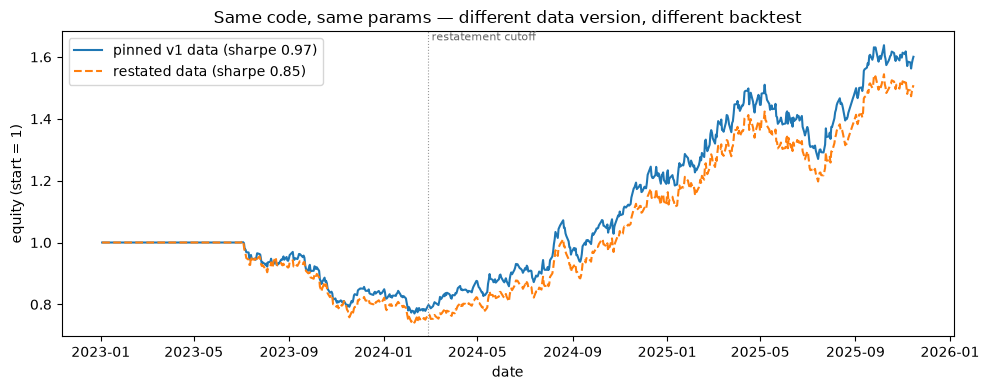

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(run1["curve"].index, run1["curve"], label=f"pinned v1 data (sharpe {run1['sharpe']:.2f})")
ax.plot(run2["curve"].index, run2["curve"], label=f"restated data (sharpe {run2['sharpe']:.2f})",
        ls="--")
ax.axvline(pd.Timestamp(cutoff), color="0.6", lw=0.8, ls=":")
ax.annotate(" restatement cutoff", xy=(pd.Timestamp(cutoff), ax.get_ylim()[1]),
            fontsize=8, va="top", color="0.4")
ax.set_title("Same code, same params — different data version, different backtest")
ax.set_xlabel("date")
ax.set_ylabel("equity (start = 1)")
ax.legend()
fig.tight_layout()

## 6. The pinned re-run is bit-identical — asserted

Now re-run against the snapshot taken before the restatement. Not "close",
not "within tolerance": the SHA-256 of the equity curve's raw float64 bytes
matches, because the inputs are the same immutable segments.

In [8]:
run3 = run_backtest("h5i('prices', 'bt-run-001')")

assert run3["sha256"] == run1["sha256"], "pinned re-run must be bit-identical"
assert np.array_equal(run3["curve"].to_numpy(), run1["curve"].to_numpy())
print(f"re-run on 'bt-run-001': sharpe={run3['sharpe']:.6f}")
print(f"curve sha256 identical: {run3['sha256'][:32]}... == {run1['sha256'][:32]}...")
print("bit-identical: PASS")

re-run on 'bt-run-001': sharpe=0.973911
curve sha256 identical: 8835f419a0b862a7f72028c73b52e050... == 8835f419a0b862a7f72028c73b52e050...
bit-identical: PASS


## 7. A minimal run registry

Make the pin discoverable: a `runs` table records run id, read point,
params (JSON), Sharpe, and the result digest. Any run in the registry can
be reproduced exactly by anyone with the database directory — the snapshot
name in the row *is* the data dependency.

In [9]:
runs_schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("run_id", pa.string()),
        pa.field("read_point", pa.string()),
        pa.field("params", pa.string()),
        pa.field("sharpe", pa.float64()),
        pa.field("curve_sha256", pa.string()),
    ]
)
db.create_table("runs", runs_schema, time_column="ts")

params = json.dumps({"strategy": "momentum", "lookback": 126, "top_n": 5, "universe": 20})
for run_id, read_point, res in [
    ("bt-run-001", "h5i('prices', 'bt-run-001')", run1),
    ("bt-run-001-naive-rerun", "prices (live head)", run2),
    ("bt-run-001-verify", "h5i('prices', 'bt-run-001')", run3),
]:
    row = pa.table(
        {
            "ts": pa.array([pd.Timestamp.now(tz="UTC")], type=pa.timestamp("us", tz="UTC")),
            "run_id": [run_id],
            "read_point": [read_point],
            "params": [params],
            "sharpe": [res["sharpe"]],
            "curve_sha256": [res["sha256"]],
        }
    )
    db.append("runs", row, note=f"register {run_id}")

db.sql(
    """
    SELECT run_id, read_point, round(sharpe, 4) AS sharpe,
           substr(curve_sha256, 1, 12) AS digest
    FROM runs ORDER BY ts
    """
).to_pandas()

,run_id,read_point,sharpe,digest
0,bt-run-001,"h5i('prices', 'bt-run-001')",0.9739,8835f419a0b8
1,bt-run-001-naive-rerun,prices (live head),0.8548,b8a42fbbe659
2,bt-run-001-verify,"h5i('prices', 'bt-run-001')",0.9739,8835f419a0b8


## Takeaways

- Backtests should take a **read point**, not a table name. Live head for
  exploration, `h5i('prices', '<snapshot>')` for anything you will ever
  have to defend.
- A snapshot is a manifest pin: O(1) to create, zero data copied, immune to
  later restatements. Compare that to the folk remedy — copying CSV extracts
  per run — which costs storage per run, drifts from the source, and cannot
  be queried with SQL.
- Restatements stay loadable the honest way: `write()` with a note creates
  a new version; the old one remains addressable forever. Data lineage is
  `versions()`, not tribal memory.
- Bit-identical means assertable: hash the result bytes and let CI verify
  that registered runs still reproduce.

In [10]:
db.close()